# Metagenomic visualization
## Introduction
In this tutorial, we will see some examples of how to visualize metagenomic data in R using a subset of the inflammatory bowel disease (IBD) cohort from the Human Microbiome Project 2 (HMP2). The original study contains a large collection of metagenomic datasets from both IBD patients and non-IBD controls. For this tutorial, we will work on a cross-sectional subset of this dataset.

### Learning objective

* Calculate alpha diversity using different indexes: Shannon index, Simpson index, etc.
* Visualize differences in alpha diversity using boxplots and perform a statistical comparison between disease groups
* Calculate beta diversity using Bray-Curtis dissimilarity
* Visualize differences in beta diversity using Principal Coordinate Analysis (PCoA) plots



### Import libraries
Please make sure that you have run through the "test_setup_R_env.ipynb" file to install the packages

In [1]:
library("vegan")
library("stringr")
library("tidyverse")
library("ggpubr")
library("ggplot2")


Loading required package: permute

-- Attaching core tidyverse packages ------------------------ tidyverse 2.0.0 --
v dplyr     1.1.4     v purrr     1.1.0
v forcats   1.0.0     v readr     2.1.5
v ggplot2   3.5.2     v tibble    3.3.0
v lubridate 1.9.4     v tidyr     1.3.1
-- Conflicts ------------------------------------------ tidyverse_conflicts() --
x dplyr::filter() masks stats::filter()
x dplyr::lag()    masks stats::lag()
i Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


## Load the datasets

Remarks: the following two functions are helpful to get an overview of the metadata table
* head() - shows the first few rows of a dataframe
* table() - returns the counts of each element

In [2]:
# load data first
root_dir = "/biodata/resources/day1_lab3"
hmp2_IBD_abd_fp = paste(root_dir,"hmp2_IBD_abd.csv",sep="/")
hmp2_IBD_metadata_fp = paste(root_dir,"hmp2_IBD_metadata.csv",sep="/")

# load metadata (input file is in csv format where columns are separated by ';')
metadata_df = read.table(hmp2_IBD_metadata_fp, sep = ";", header = TRUE)

# assign rownames using the sample ids
rownames(metadata_df)=metadata_df$sample_id

# load relative abundances
spp_abd_df = read.table(hmp2_IBD_abd_fp, sep = ";", header = TRUE, row.names = 1)

#### TASK: Overview of the dataset
* How many samples are there?
* How many patients in each disease groups?

In [3]:
# check data:
print(dim(metadata_df))
print(dim(spp_abd_df))

# print the first few rows of the metadata
print(head(metadata_df))

# count how many patients are in each disease group
print(table(metadata_df[colnames(spp_abd_df),]$disease))


[1] 127   3
[1] 585 127
            sample_id disease dysbiosis
CSM5FZ3N_P CSM5FZ3N_P     IBD 0.7923148
CSM5FZ3T_P CSM5FZ3T_P     IBD 0.9242969
CSM5FZ4E_P CSM5FZ4E_P     IBD 0.7876165
CSM5FZ4A_P CSM5FZ4A_P     IBD 0.7751605
CSM5MCUQ_P CSM5MCUQ_P     IBD 0.7278737
CSM5MCTZ_P CSM5MCTZ_P     IBD 0.6904776

Control     IBD 
     27     100 


#### Your solution:

In [4]:
# write the code for your solution here
# "table" function
head(metadata_df)

,sample_id,disease,dysbiosis
,<chr>,<chr>,<dbl>
CSM5FZ3N_P,CSM5FZ3N_P,IBD,0.7923148
CSM5FZ3T_P,CSM5FZ3T_P,IBD,0.9242969
CSM5FZ4E_P,CSM5FZ4E_P,IBD,0.7876165
CSM5FZ4A_P,CSM5FZ4A_P,IBD,0.7751605
CSM5MCUQ_P,CSM5MCUQ_P,IBD,0.7278737
CSM5MCTZ_P,CSM5MCTZ_P,IBD,0.6904776


In [5]:
dim(metadata_df)
dim(spp_abd_df)

[1] 127   3

[1] 585 127

In [6]:
#

# Alpha diversity: intra-sample diversity:

In [7]:
# calculate the shannon diversity using the "diversity" function
shannon_div = data.frame(diversity(t(spp_abd_df), index = "shannon"))

# assign a column name
colnames(shannon_div) = c("shannon_div")

# get the disease information for each sample
shannon_div$disease = metadata_df[row.names(shannon_div),]$disease

# set the order of the samples by disease group
shannon_div$disease = factor(shannon_div$disease, levels=c("Control", "IBD"))

In [8]:
head(shannon_div)

,shannon_div,disease
,<dbl>,<fct>
CSM5FZ3N_P,1.652059,IBD
CSM5FZ3T_P,1.071517,IBD
CSM5FZ4E_P,2.068625,IBD
CSM5FZ4A_P,1.774525,IBD
CSM5MCUQ_P,2.716136,IBD
CSM5MCTZ_P,2.672129,IBD


#### TASK: Examine the Shannon diversity
* What is the mean, median, and standard deviation of the shannon index in each disease group, respectively? (hint: the [aggregate](https://r-coder.com/aggregate-r/) function)

In [9]:
# group by disease state and calculate the mean Shannon diversity of each group
print(aggregate(shannon_div$shannon_div,by=list(shannon_div$disease),FUN=mean))

# group by disease state and calculate the median Shannon diversity of each group
print(aggregate(shannon_div$shannon_div,by=list(shannon_div$disease),FUN=median))

# group by disease state and calculate the standard divition Shannon diversity of each group
print(aggregate(shannon_div$shannon_div,by=list(shannon_div$disease),FUN=sd))
#

  Group.1        x
1 Control 2.393862
2     IBD 2.151396
  Group.1        x
1 Control 2.420881
2     IBD 2.257902
  Group.1         x
1 Control 0.4868472
2     IBD 0.5338220


#### Your solution:

In [10]:
# write your solution here:


### Visualization using a boxplot

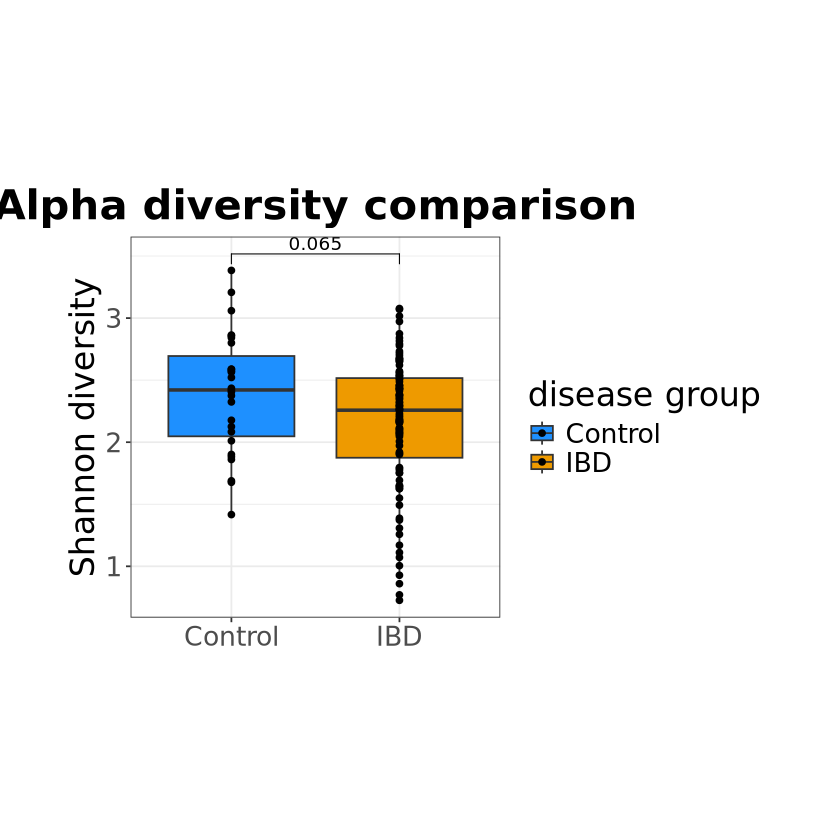

In [11]:
# Generate the boxplot:
my_comparisons <- list(c("Control", "IBD"))
p = ggplot(shannon_div, aes(x=disease, y=shannon_div, fill=disease)) + geom_boxplot(outlier.shape = NA)
p = p + geom_point()
p = p + theme_bw()
p = p + ggtitle("Alpha diversity comparison") + theme(axis.title.x=element_blank(),
                text=element_text(size=20), plot.title = element_text(size = 25, face = "bold", hjust=0.5))
p = p + ylab("Shannon diversity")
p = p + scale_fill_manual(name="disease group", values = c("dodgerblue", "orange2"))
p = p + stat_compare_means(comparisons = my_comparisons, method = "wilcox.test")


print(p, vp=grid::viewport(width=unit(6, 'inch'), height=unit(4, 'inch')))

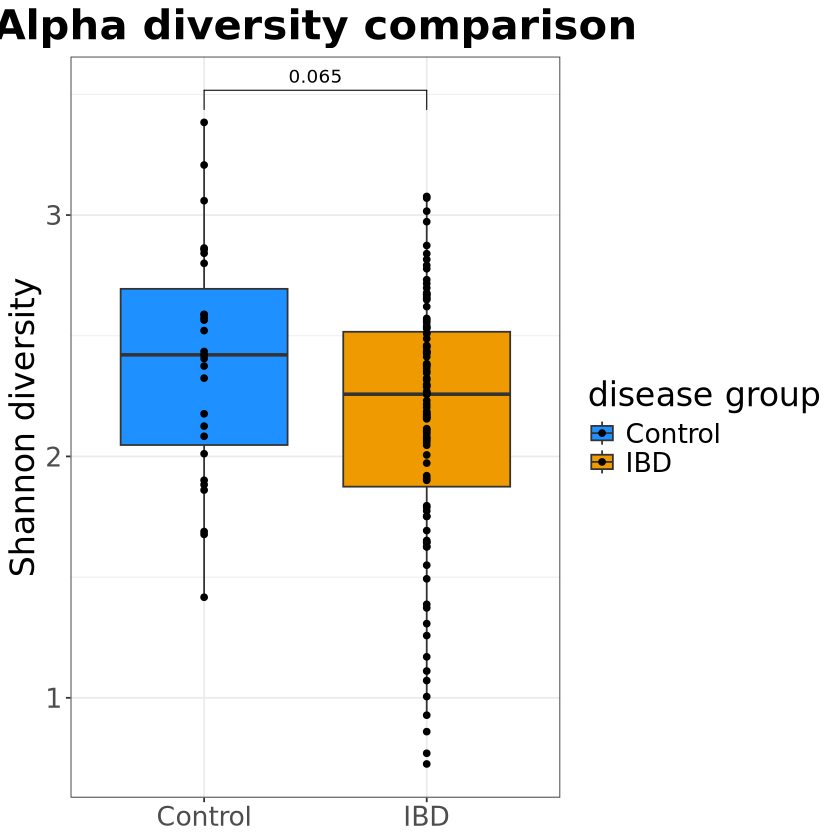

In [12]:

# Generate the boxplot:
my_comparisons <- list(c("Control", "IBD"))
p = ggplot(shannon_div, aes(x=disease, y=shannon_div, fill=disease)) + geom_boxplot(outlier.shape = NA)
p = p + geom_point()
p = p + theme_bw()
p = p + ggtitle("Alpha diversity comparison") + theme(axis.title.x=element_blank(),
                text=element_text(size=20), plot.title = element_text(size = 25, face = "bold", hjust=0.5))
p = p + ylab("Shannon diversity")
p = p + scale_fill_manual(name="disease group", values = c("dodgerblue", "orange2"))
p = p + stat_compare_means(comparisons = my_comparisons, method = "wilcox.test")
print(p)

####TASK: calculate alpha diversity using the Simpson index

Hint:

> You can find the definition of Sympson index [here](https://entnemdept.ufl.edu/hodges/protectus/lp_webfolder/9_12_grade/student_handout_1a.pdf)

> The "diversity" function we used previously can be altered to calculated the Simpson index, more details [here](https://search.r-project.org/CRAN/refmans/vegan/html/diversity.html)

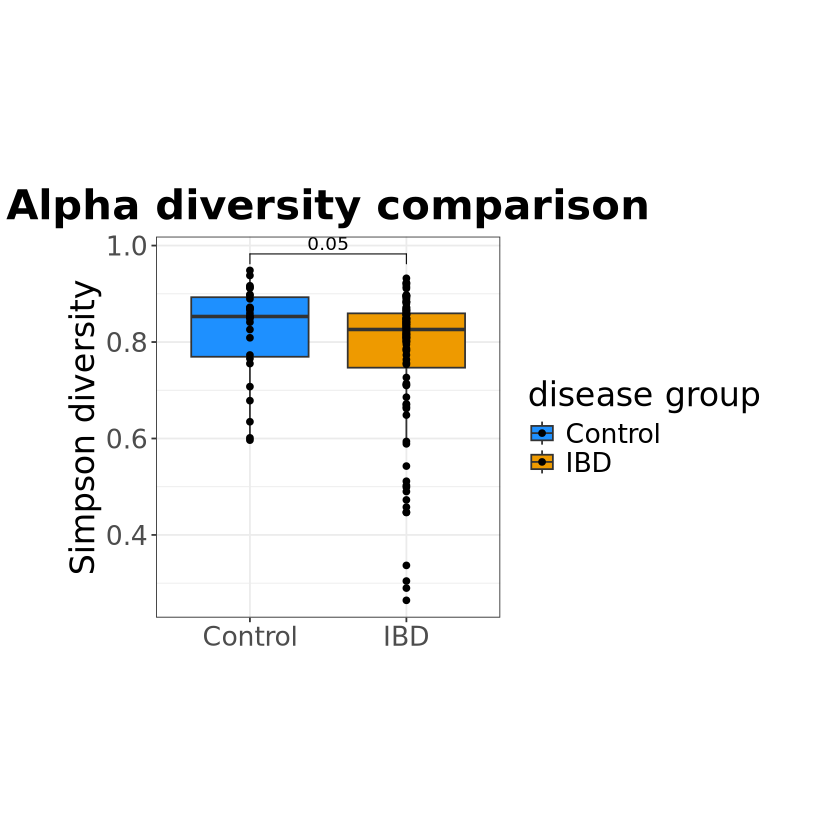

In [13]:

# calculate the shannon diversity using the "diversity" function
simpson_div = data.frame(diversity(t(spp_abd_df), index = "simpson"))

# assign a column name
colnames(simpson_div) = c("simpson_div")

# get the disease information for each sample
simpson_div$disease = metadata_df[row.names(simpson_div),]$disease

# set the order of the samples by disease group
simpson_div$disease = factor(simpson_div$disease, levels=c("Control", "IBD"))

# Generate the boxplot:
my_comparisons <- list(c("Control", "IBD"))
p = ggplot(simpson_div, aes(x=disease, y=simpson_div, fill=disease)) + geom_boxplot(outlier.shape = NA)
p = p + geom_point()
p = p + theme_bw()
p = p + ggtitle("Alpha diversity comparison") + theme(axis.title.x=element_blank(),
                text=element_text(size=20), plot.title = element_text(size = 25, face = "bold", hjust=0.5))
p = p + ylab("Simpson diversity")
p = p + scale_fill_manual(name="disease group", values = c("dodgerblue", "orange2"))
p = p + stat_compare_means(comparisons = my_comparisons, method = "wilcox.test")
print(p, vp=grid::viewport(width=unit(6, 'inch'), height=unit(4, 'inch')))

####Here is your solution:

In [14]:
# write the code for your solution here


# Beta diversity: inter-sample diversity
Beta diversity is a measurement to compare the microbial community composition across samples. The Bray-Curtis dissimilarity is one of the most common beta diversity measurements for microbiome data. Next, we will calculate the Bray-Curtis dissimilarity for our samples and visualize the result in a principal coordinate analysis (PCoA).

In [15]:

# calculate the Bray-Curtis dissimilarity using the function "vegdist".
braycurtis <- vegdist(t(spp_abd_df), "bray")

In [16]:

dim(spp_abd_df)
head(braycurtis)

[1] 585 127

[1] 0.4728087 0.6209444 0.4133789 0.8319405 0.6132534 0.9515606

### Prepare the data for the PCoA plot



In [17]:

# calculate the principal coordinates (axis) and the eigenvalue to infer the variation explained by each principal coordinate (PCs)
# set k=2 to retrieve the first two PCs for a 2D visualization
tmp_pcoa <- cmdscale(braycurtis, k=2, eig=TRUE)

# We are going to draw a 2D scatter plot, where each sample will represented by a point, the distance between the points indicates how similar the community composition between the samples is
# Save the coordinates for each sample as a dataframe
my_points = data.frame(tmp_pcoa$points)
colnames(my_points) = c("PC1","PC2")

# Add the disease state information for each sample
my_points$disease = metadata_df[row.names(my_points), "disease"]

# We will also save the dysbiosis score of each sample to the dataframe
my_points$dysbiosis = metadata_df[rownames(my_points),]$dysbiosis

# Calculate how much variation is explained by the first and second PC
# In case some eigenvalues are negative, the abs() function will return the absolute value. These values should be small and this should _not_ be the case for the first few PCs.
pcoa_percentage = round(tmp_pcoa$eig*100 / sum(abs(tmp_pcoa$eig)), 1)
pcoa_percentage = paste(colnames(my_points), "(", paste( as.character(pcoa_percentage), "%", ")", sep="") )
pcoa_percentage = str_replace(pcoa_percentage, "axis", "PCoA")

In [18]:

head(my_points)

,PC1,PC2,disease,dysbiosis
,<dbl>,<dbl>,<chr>,<dbl>
CSM5FZ3N_P,-0.28160620,0.07743675,IBD,0.7923148
CSM5FZ3T_P,-0.27535232,0.21853331,IBD,0.9242969
CSM5FZ4E_P,0.04696255,-0.34049030,IBD,0.7876165
CSM5FZ4A_P,-0.26336287,-0.05363182,IBD,0.7751605
CSM5MCUQ_P,0.10165185,-0.36728513,IBD,0.7278737
CSM5MCTZ_P,-0.15166572,0.03645918,IBD,0.6904776


### Visualization using a scatter plot

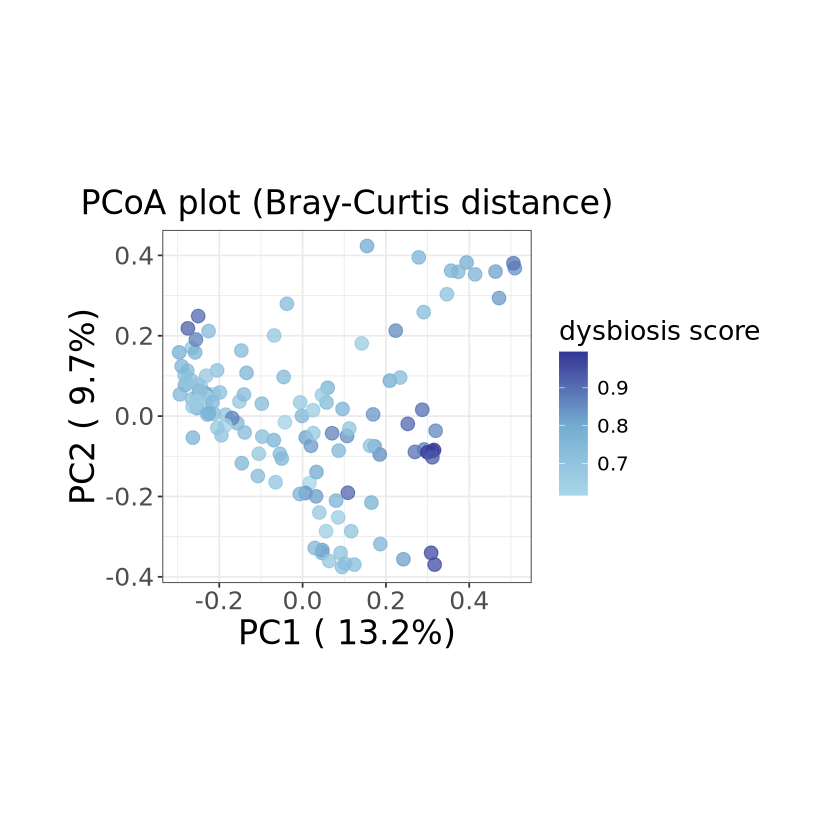

In [19]:

# plot the first and the second PC as the x and y axis
# color will indicates the dysbiosis score
plt = ggplot(data = my_points, aes(x = PC1, y = PC2, colour=dysbiosis, label = row.names(my_points)))

# draw the scatter plot, alpha=0.5 will control the transparency of the points
plt = plt + geom_point(alpha=0.75, size=3.5)

# add a plot and axis title including the variation explained by each axis
plt = plt + theme_bw() + labs(title = "PCoA plot (Bray-Curtis distance)")
plt = plt + xlab(pcoa_percentage[1]) + ylab(pcoa_percentage[2])
plt = plt + labs(colour = "dysbiosis score")

# change the colors (see https://colorbrewer2.org/#type=diverging&scheme=RdYlBu&n=11)
plt = plt + scale_color_gradient2(low="#abd9e9", mid="#74add1", high="#313695", midpoint=0.8)

# set the font sizes
plt = plt + theme(axis.text.x = element_text(size=15),
                  axis.text.y = element_text(size=15),
                  axis.title.x=element_text(size=20),
                  axis.title.y=element_text(size=20),
                  legend.text = element_text(size=12),
                  legend.title = element_text(size=16),
                  plot.title = element_text(size=20, hjust = 0.5))

# generate the plot
print(plt, vp=grid::viewport(width=unit(6, 'inch'), height=unit(4, 'inch')))

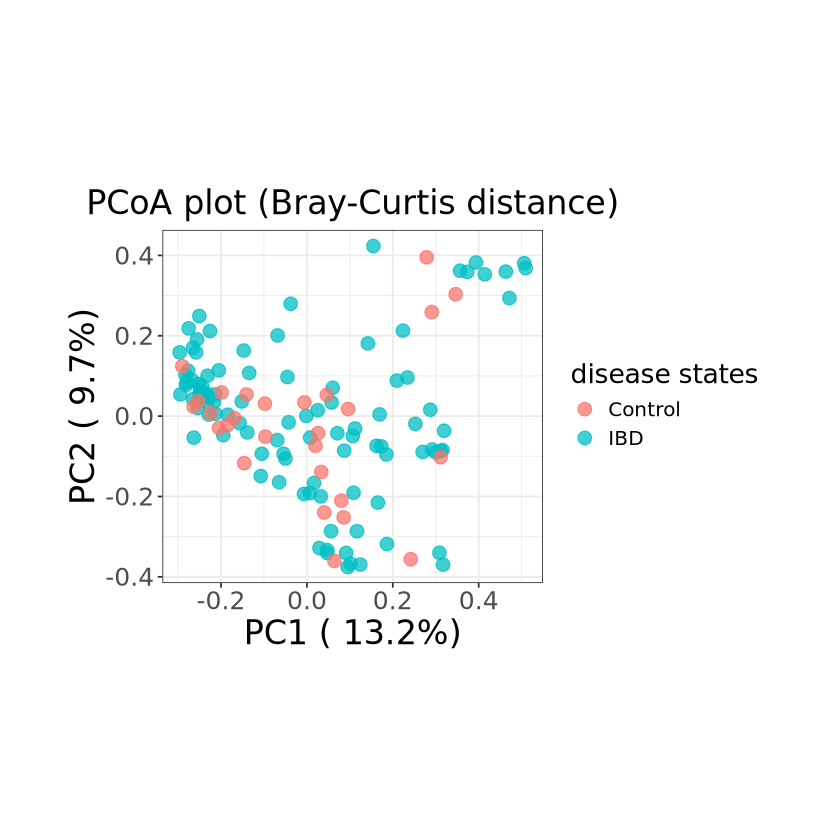

In [20]:

# plot the first and the second PC as the x and y axis
# color will indicates the dysbiosis score
plt = ggplot(data = my_points, aes(x = PC1, y = PC2, colour=disease, label = row.names(my_points)))

# draw the scatter plot, alpha=0.5 will control the transparency of the points
plt = plt + geom_point(alpha=0.75, size=3.5)

# add a plot and axis title including the variation explained by each axis
plt = plt + theme_bw() + labs(title = "PCoA plot (Bray-Curtis distance)")
plt = plt + xlab(pcoa_percentage[1]) + ylab(pcoa_percentage[2])
plt = plt + labs(colour = "disease states")

# change the colors (see https://colorbrewer2.org/#type=diverging&scheme=RdYlBu&n=11)
# plt = plt + scale_color_gradient2(low="#abd9e9", mid="#74add1", high="#313695", midpoint=0.8)

# set the font sizes
plt = plt + theme(axis.text.x = element_text(size=15),
                  axis.text.y = element_text(size=15),
                  axis.title.x=element_text(size=20),
                  axis.title.y=element_text(size=20),
                  legend.text = element_text(size=12),
                  legend.title = element_text(size=16),
                  plot.title = element_text(size=20, hjust = 0.5))

# generate the plot
print(plt, vp=grid::viewport(width=unit(6, 'inch'), height=unit(4, 'inch')))